In [1]:
import mne
import pandas as pd
import numpy as np
import os

# from asrpy import ASR
import matplotlib.pyplot as plt
from mne.preprocessing import ICA, corrmap, create_ecg_epochs, create_eog_epochs

%matplotlib qt

Función de lectura de archivos

In [2]:
# def data_reading(filename_eeg, filename_unity):
def data_reading(filename_eeg):
    ''' Función encargada de leer los archivos de EEG, guardarlos en los formatos adecuados y leer los eventos'''
    
    montage = mne.channels.make_standard_montage('biosemi64')
    montage.ch_names = [element.upper() for element in montage.ch_names]

    eeg_raw = mne.io.read_raw_cnt(filename_eeg, preload=True)
    # Lectura de eventos desde las anotaciones del archivo.
    events_times, events_id = mne.events_from_annotations(eeg_raw)

    # Corrijo las posiciones de los electrodos en el montaje, porque espacialmente están en cualquiera
    # eeg_raw.rename_channels(mapping=dict(Po3='PO3', Fp1='FP1', Fp2='FP2', Fz='FZ', Cz='CZ', Pz='PZ' ))
    # eeg_raw.rename_channels(mapping=dict(Po3='PO3', Fp1='FP1', Fp2='FP2'))
    eeg_raw.rename_channels(mapping=dict(Fz='FZ', Cz='CZ', Pz='PZ'))
    eeg_raw.set_montage(montage)

    # unity_data = pd.read_csv(filename_unity, sep=",")

    # return eeg_raw, unity_data, events_times, events_id
    return eeg_raw, events_times, events_id

    

### Lectura de archivo

In [ ]:
data_folder = 'G:/My Drive/2.2-Experiment_1/00-Data/01-Experiment'
data_subject_eeg = '/S00(23-08-23)/01-N-back/00-EEG/'
block = 's00nb_b2'

raw, event_t, event_id = data_reading(data_folder + data_subject_eeg + block +'.cnt')

raw.plot()

C:\Users\eliyo\AppData\Local\Temp\ipykernel_19192\2264772387.py:8: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  eeg_raw = mne.io.read_raw_cnt(filename_eeg, preload=True)


Reading 0 ... 48869  =      0.000 ...   195.476 secs...
Used Annotations descriptions: [np.str_('126'), np.str_('190')]
Using qt as 2D backend.


Channels marked as bad:
none
Attempting to create new mne-python configuration file:
C:\Users\eliyo\.mne\mne-python.json
Could not read the C:\Users\eliyo\.mne\mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)


In [4]:
raw.info['ch_names']

['FP1',
 'FP2',
 'F3',
 'FZ',
 'F4',
 'C3',
 'CZ',
 'C4',
 'P3',
 'PZ',
 'P4',
 'PO7',
 'PO3',
 'PO4',
 'PO8']

In [6]:
raw.compute_psd()

Effective window size : 8.192 (s)


Data type,Power Spectrum
Units,eeg: V²/Hz
Data source,Raw
Dims,"channel, freq"
Estimation method,welch
Number of channels,15
Number of frequency bins,1025
Frequency range,0.00 – 125.00 Hz


Channels marked as bad:
none


In [ ]:
# Cambiar x sujeto
# suj = 's26nb'
suj = 's30cc'
# filepath_EEG= 'I:/Mi unidad/2.2-Experiment_1/00-Data/01-Experiment/S10(28-09-23)/01-N-back/00-EEG/'
filepath_EEG = 'I:/Mi unidad/2.2-Experiment_1/00-Data/01-Experiment/S30(01-12-23)/00-CC/00-EEG/'
# filepath_unity= 'G:/Mi unidad/2.2-Experiment_1/00-Data/01-Experiment/S00(23-08-23)/01-N-back/01-Unity/'

filt_nb = []
# bloques = [1,2,3,5]
for b in range(1,11): # para CDA
# for b in range(1,6): # para n-back
# for b in bloques:
    # Lectura de datos
    filename_eeg = filepath_EEG + suj + '_b' + str(b) + '.cnt'
    eeg_data, events, ev_id = data_reading (filename_eeg)

    #Filtrado de los datos
    filt_raw = eeg_data.copy().filter(l_freq = None , h_freq = 30, method='iir', iir_params={'order': 4, 'ftype': 'butter', 'output': 'sos'})

    filt_nb.append(filt_raw)

# Concatenado de todos los bloques para ICA

tot_filt_nb = mne.concatenate_raws(filt_nb)

In [13]:
tot_filt_nb.plot()

### Filtrado y re-referenciado

In [41]:
# Filtrado de los datos
filt_raw = raw.copy().filter(l_freq = None , h_freq = 30, method='iir', iir_params={'order': 4, 'ftype': 'butter', 'output': 'sos'})

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 30 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 30.00 Hz: -6.02 dB



In [ ]:
# Re-referenciado de los datos

# ref_data = filt_raw.copy().set_eeg_reference(ref_channels="average")

In [ ]:
# La división por épocas es a modo de visualizazción. Se guardan los datos continuos

# epochs = mne.Epochs(filt_raw, event_t, event_id=2,
#                         tmin=-0.2, tmax=2.5, baseline = None, verbose= False, preload=True)

# avg = epochs.average()

In [ ]:


# avg.plot()

# time = epochs.times
# plt.plot(time, np.squeeze(epochs.get_data(picks='FP1')).transpose(1,0),label='Cz',color='black')
# plt.show()


In [ ]:
save_path = data_folder + data_subject_eeg + block + '_filt_raw.fif'
print(save_path)

filt_raw.save(save_path)

### Filtrado con ASR


In [ ]:
# asr = ASR(sfreq=filt_raw.info["sfreq"], cutoff=5)
# asr.fit(filt_raw)
# asr_data = asr.transform(filt_raw)

Graficación de los datos antes y después de filtrar

In [ ]:
ylim = dict(eeg=[-10, 20])

# Plot data before ASR

# ref_data.plot()
filt_raw.plot()

# Plot data after ASR

asr_data.plot()

Channels marked as bad:
none
Channels marked as bad:
none


### Rechazo de artefactos con ICA

In [23]:
ica = ICA(n_components=15, max_iter="auto", random_state=97)
# ica.fit(ep_tot)
ica.fit(filt_raw)
# ica.fit(tot_filt_nb)
ica

Fitting ICA to data using 15 channels (please be patient, this may take a while)
Selecting by number: 15 components


C:\Users\FIUNER\AppData\Local\Temp\ipykernel_2208\2543421863.py:3: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(filt_raw)


Fitting ICA took 0.8s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,33 iterations on raw data (59350 samples)
ICA components,15
Available PCA components,15
Channel types,eeg
ICA components marked for exclusion,—


In [24]:
# explained_var_ratio = ica.get_explained_variance_ratio(
#     tot_filt_nb, components=[0,1,2,3], ch_type="eeg"
#     # ep_tot, components=[0], ch_type="eeg"
# )

explained_var_ratio = ica.get_explained_variance_ratio(
    filt_raw, components=[0,1,2,3], ch_type="eeg"
#     # ep_tot, components=[0], ch_type="eeg"
)

ratio_percent = round(100 * explained_var_ratio["eeg"])
print(
    f"Fraction of variance in EEG signal explained by first component: "
    f"{ratio_percent}%"
)

Fraction of variance in EEG signal explained by first component: 84%


In [25]:
# filt_raw.load_data()
# ica.plot_sources(tot_filt_nb, show_scrollbars=False),
ica.plot_sources(filt_raw, show_scrollbars=False),

Creating RawArray with float64 data, n_channels=15, n_times=59350
    Range : 0 ... 59349 =      0.000 ...   237.396 secs
Ready.


(<mne_qt_browser._pg_figure.MNEQtBrowser at 0x2b75fe23b50>,)

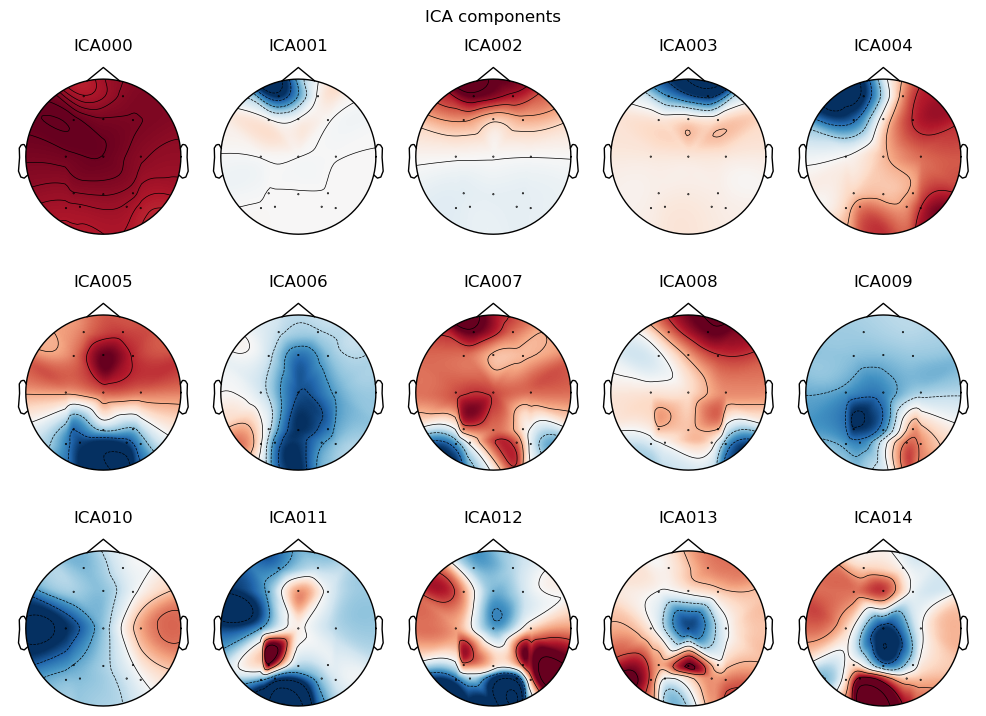

In [26]:
ica.plot_components()

In [27]:
# ica.plot_properties(tot_filt_nb, picks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])
ica.plot_properties(filt_raw, picks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])

# ica.plot_properties(ep_tot, picks=[0, 1,2,3,4,5,6,7,8,9,10,11,12,13])

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
118 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
118 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
118 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
118 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
118 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
118 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
118 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
118 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
118 matching events found
No baseline correction applied
0 pro

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 5 ICA components
    Projecting back using 15 PCA components


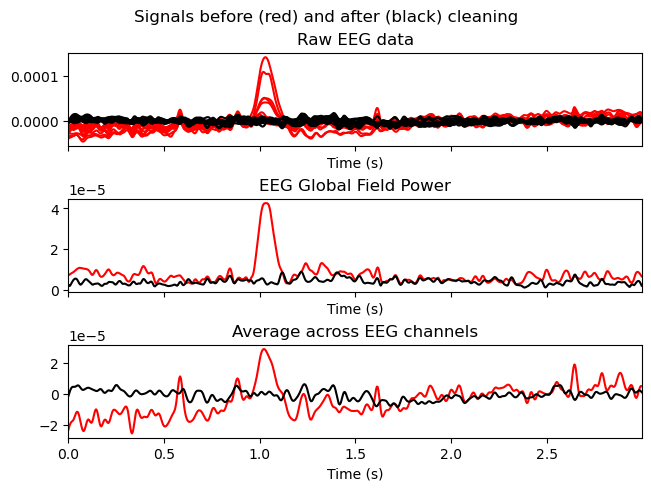

In [29]:
ic_exclude = [0,1,2,3,11]
ica.plot_overlay(filt_raw, exclude = ic_exclude, picks="eeg")
# ica.plot_overlay(tot_filt_nb, exclude = ic_exclude, picks="eeg")

In [31]:
ica.exclude = ic_exclude
# filt_ica_raw = tot_filt_nb.copy()
filt_ica_raw = filt_raw.copy()
ica.apply(filt_ica_raw)

Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 5 ICA components
    Projecting back using 15 PCA components


<RawCNT | s00nb_b1.cnt, 15 x 59350 (237.4 s), ~6.8 MB, data loaded>

In [32]:
filt_ica_raw.plot()

Channels marked as bad:
none


### División de los bloques y guardado de datos

In [164]:
annot = filt_ica_raw.annotations # Extraigo las anotaciones del archivo concatenado
anot_pd = annot.to_data_frame() # Transformo las anotaciones en dataframe
anot_c = anot_pd.loc[(anot_pd.description == 'BAD boundary')] # Me quedo solo con las anotaciones que me dan los limites de los bloques
idx = list(anot_c.index) # Extraigo los indices a los que corresponden esas anotaciones
idx.insert(0,0)
idx.append(None)

n_blocks = 10

for i in range(n_blocks):
    if i < (n_blocks-1):
        aux = filt_ica_raw.copy().crop(tmin=annot[idx[i]]['onset'],tmax=annot[idx[i+1]]['onset'])
    elif i == (n_blocks-1):
        aux = filt_ica_raw.copy().crop(tmin=annot[idx[i]]['onset'])

    
    save_path = filepath_EEG + suj + '_b' + str(i + 1) + '_filt_ica_raw.fif'
      
    print(save_path)

    aux.save(save_path)
# # print(aux.info)




# b1 = filt_ica_raw.copy().crop(tmin=annot[idx[0]]['onset'],tmax=annot[idx[1]]['onset'])
# b2 = filt_ica_raw.copy().crop(tmin=annot[idx[1]]['onset'],tmax=annot[idx[2]]['onset'])
# b3 = filt_ica_raw.copy().crop(tmin=annot[idx[2]]['onset'],tmax=annot[idx[3]]['onset'])
# b4 = filt_ica_raw.copy().crop(tmin=annot[idx[3]]['onset'],tmax=annot[idx[4]]['onset'])
# b5 = filt_ica_raw.copy().crop(tmin=annot[idx[4]]['onset'])



I:/Mi unidad/2.2-Experiment_1/00-Data/01-Experiment/S30(01-12-23)/00-CC/00-EEG/s30cc_b1_filt_ica_raw.fif
Writing I:\Mi unidad\2.2-Experiment_1\00-Data\01-Experiment\S30(01-12-23)\00-CC\00-EEG\s30cc_b1_filt_ica_raw.fif
Closing I:\Mi unidad\2.2-Experiment_1\00-Data\01-Experiment\S30(01-12-23)\00-CC\00-EEG\s30cc_b1_filt_ica_raw.fif
[done]
I:/Mi unidad/2.2-Experiment_1/00-Data/01-Experiment/S30(01-12-23)/00-CC/00-EEG/s30cc_b2_filt_ica_raw.fif
Writing I:\Mi unidad\2.2-Experiment_1\00-Data\01-Experiment\S30(01-12-23)\00-CC\00-EEG\s30cc_b2_filt_ica_raw.fif
Closing I:\Mi unidad\2.2-Experiment_1\00-Data\01-Experiment\S30(01-12-23)\00-CC\00-EEG\s30cc_b2_filt_ica_raw.fif
[done]
I:/Mi unidad/2.2-Experiment_1/00-Data/01-Experiment/S30(01-12-23)/00-CC/00-EEG/s30cc_b3_filt_ica_raw.fif
Writing I:\Mi unidad\2.2-Experiment_1\00-Data\01-Experiment\S30(01-12-23)\00-CC\00-EEG\s30cc_b3_filt_ica_raw.fif
Closing I:\Mi unidad\2.2-Experiment_1\00-Data\01-Experiment\S30(01-12-23)\00-CC\00-EEG\s30cc_b3_filt_ica_r

### Guardado de datos

In [ ]:
# # Guardo los datos pre-procesados

# save_path = data_folder + data_subject_eeg + block + '_filt_ica_asr_raw.fif'
# print(save_path)

# filt_ica_raw.save(save_path)


# del filt_ica_raw, raw, asr, asr_data,

G:/Mi unidad/2.2-Experiment_1/00-Data/01-Experiment/S00(23-08-23)/01-N-back/00-EEG/s00nb_b1_filt_ica_asr_raw.fif
Writing G:\Mi unidad\2.2-Experiment_1\00-Data\01-Experiment\S00(23-08-23)\01-N-back\00-EEG\s00nb_b1_filt_ica_asr_raw.fif
Closing G:\Mi unidad\2.2-Experiment_1\00-Data\01-Experiment\S00(23-08-23)\01-N-back\00-EEG\s00nb_b1_filt_ica_asr_raw.fif
[done]
